# Regularization (Recap), Hyperparameter Tuning & Confidence Intervals

In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, KFold
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, MinMaxScaler, StandardScaler, PolynomialFeatures
from sklearn.linear_model import Ridge, Lasso, ElasticNet

import matplotlib.pyplot as plt
%matplotlib inline
plt.style.use('bmh')

In [2]:
def NoisySinusoidalData(N, a, b, sigma):
    '''Generates N data points in the range [a,b) sampled from a sin(2*pi*x) 
    with additive zero-mean Gaussian random noise with standard deviation sigma'''
    
    # N input samples, evenly spaced numbers between [a,b) incrementing by 1/N
    x = np.linspace(a,b,N)
    
    # draw N sampled from a univariate Gaussian distribution with mean 0, sigma standard deviation and N data points
    noise = np.random.normal(0,sigma,N)
    
    # desired values, noisy sinusoidal
    t = np.sin(2*np.pi*x) + noise
    
    return x.reshape(-1,1), t

In [3]:
# Generate input samples and desired values
N_train = 50 # number of data samples for training
N_test = 20 # number of data samples for test

a, b = [0,1] # data samples interval

sigma_train = 0.3 # standard deviation of the zero-mean Gaussian noise -- training data
sigma_test = 0.4 # standard deviation of the zero-mean Gaussian noise -- test data

x_train, t_train = NoisySinusoidalData(N_train, a, b, sigma_train) # Training Data - Noisy sinusoidal
x_true, t_true = NoisySinusoidalData(N_train, a, b, 0) # True Sinusoidal - in practice, we don't have the true function
x_test, t_test = NoisySinusoidalData(N_test, a, b, sigma_test) # Test Data - Noisy sinusoidal

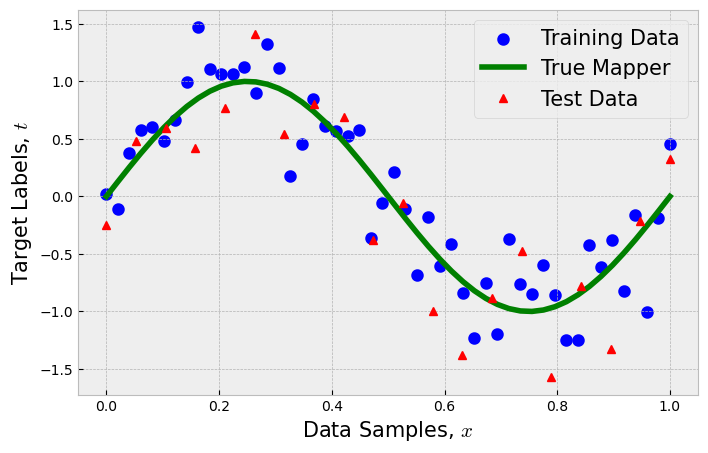

In [4]:
plt.figure(figsize=(8,5))
plt.scatter(x_train, t_train, c='b', linewidths=3, label = 'Training Data')
plt.plot(x_true, t_true, 'g', linewidth=4, label = 'True Mapper')
plt.plot(x_test, t_test, 'r^', label = 'Test Data')
plt.legend(fontsize=15)
plt.xlabel('Data Samples, $x$',size=15)
plt.ylabel('Target Labels, $t$',size=15);

---

## Strategies of Experimentation

To fully test a system, you want to try to evaluate each of these parameters separately. However, this is often not easily done.

A few strategies for fine-tuning hyperparameters include:

* Best guess
* One factor at a time
* Factorial design or **grid search**
* Randomized search

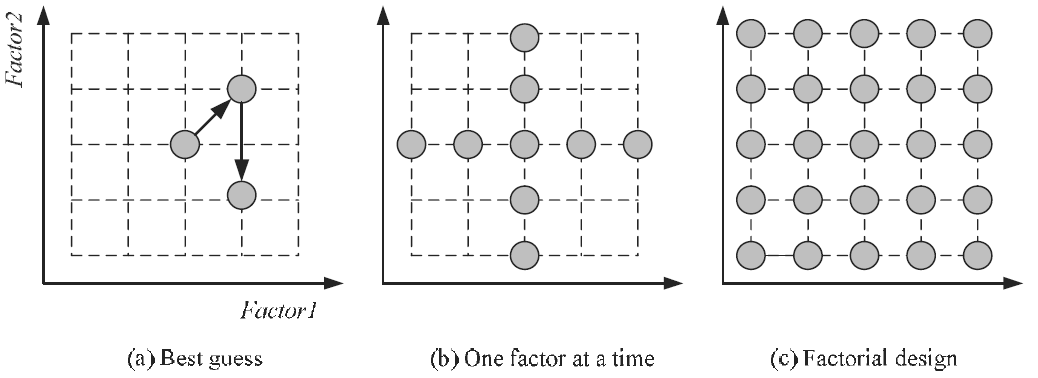

In [5]:
from IPython.display import Image
Image('figures\\Experimentation.png',width=800)
# Source: Alpaydin, E. (2014) Introduction to Machine Learning. 3rd edition, MIT Press.

## Grid Search

One option would be to fiddle with the hyperparameters manually, until you find a great combination of hyperparameter values. This would be very tedious work, and you may not have time to explore many combinations.

Instead, you should get ```Scikit-Learn```'s ```GridSearchCV``` to search for you. All you need to do is tell it which hyperparameters you want it to experiment with and what values to try out, and it will use cross-validation to evaluate all the possible combinations of hyperparameter values. For example, the following code searches for the best combination of hyperparameter values for the Polynomial Regression with Ridge regularization.

In [6]:
from sklearn.model_selection import GridSearchCV

GridSearchCV?

In [7]:
pipe = Pipeline([('poly_feat', PolynomialFeatures()),
                ('ridge_reg', Ridge())])

In [8]:
pipe.get_params()

{'memory': None,
 'steps': [('poly_feat', PolynomialFeatures()), ('ridge_reg', Ridge())],
 'verbose': False,
 'poly_feat': PolynomialFeatures(),
 'ridge_reg': Ridge(),
 'poly_feat__degree': 2,
 'poly_feat__include_bias': True,
 'poly_feat__interaction_only': False,
 'poly_feat__order': 'C',
 'ridge_reg__alpha': 1.0,
 'ridge_reg__copy_X': True,
 'ridge_reg__fit_intercept': True,
 'ridge_reg__max_iter': None,
 'ridge_reg__positive': False,
 'ridge_reg__random_state': None,
 'ridge_reg__solver': 'auto',
 'ridge_reg__tol': 0.0001}

In [9]:
# Grid of parameter values for the hyperparameters

param_grid = {'poly_feat__degree': list(range(3, 11)),
             'ridge_reg__alpha': [0, 0.001,0.01,0.1,0.2,0.5,1]}

In [11]:
grid_search = GridSearchCV(pipe,
                          param_grid=param_grid,
                          cv=KFold(5, shuffle=True, random_state=0),
                          scoring='neg_mean_squared_error',
                          refit=True)

In [12]:
grid_search

GridSearchCV(cv=KFold(n_splits=5, random_state=0, shuffle=True),
             estimator=Pipeline(steps=[('poly_feat', PolynomialFeatures()),
                                       ('ridge_reg', Ridge())]),
             param_grid={'poly_feat__degree': [3, 4, 5, 6, 7, 8, 9, 10],
                         'ridge_reg__alpha': [0, 0.001, 0.01, 0.1, 0.2, 0.5,
                                              1]},
             scoring='neg_mean_squared_error')

In [13]:
grid_search.fit(x_train, t_train)

GridSearchCV(cv=KFold(n_splits=5, random_state=0, shuffle=True),
             estimator=Pipeline(steps=[('poly_feat', PolynomialFeatures()),
                                       ('ridge_reg', Ridge())]),
             param_grid={'poly_feat__degree': [3, 4, 5, 6, 7, 8, 9, 10],
                         'ridge_reg__alpha': [0, 0.001, 0.01, 0.1, 0.2, 0.5,
                                              1]},
             scoring='neg_mean_squared_error')

Done!

Let's check the best set of hyperparameters based on the training data:

In [14]:
grid_search.best_params_

{'poly_feat__degree': 3, 'ridge_reg__alpha': 0}

You can also get the estimator directly (thus avoiding having to retrain it):

In [15]:
grid_search.best_estimator_

Pipeline(steps=[('poly_feat', PolynomialFeatures(degree=3)),
                ('ridge_reg', Ridge(alpha=0))])

If ```GridSearchCV``` is initialized with ```refit=True``` (which is the default), then once it finds the best estimator using cross-validation, it retrains it on the whole training set. This is usually a good idea, since feeding it more data will likely improve its performance.

The evaluation scores are also available:

In [16]:
cvres = grid_search.cv_results_

cvres

{'mean_fit_time': array([0.00488071, 0.00303974, 0.00282645, 0.00232902, 0.00181875,
        0.00315809, 0.00323877, 0.00343227, 0.0044157 , 0.00436139,
        0.00410471, 0.00424399, 0.00465651, 0.00594339, 0.00507894,
        0.00493803, 0.00473828, 0.0048562 , 0.00353107, 0.0040235 ,
        0.00597982, 0.00488386, 0.00354128, 0.00437546, 0.01105318,
        0.03258085, 0.01013427, 0.0050549 , 0.00734916, 0.02886167,
        0.02322965, 0.02238641, 0.00941353, 0.0110045 , 0.01984453,
        0.00481558, 0.00303741, 0.00389681, 0.0050581 , 0.00328135,
        0.00343518, 0.0034306 , 0.00611038, 0.00471177, 0.00402083,
        0.00530119, 0.0045207 , 0.00341401, 0.00318217, 0.00332174,
        0.00283008, 0.00323682, 0.00402641, 0.00299873, 0.00391707,
        0.00843101]),
 'std_fit_time': array([0.00182666, 0.00086031, 0.00073577, 0.00082843, 0.00052347,
        0.00112029, 0.00076688, 0.00117255, 0.0015045 , 0.00166004,
        0.00164174, 0.00154772, 0.00223408, 0.00203984, 0.002

In [17]:
cvres.keys()

dict_keys(['mean_fit_time', 'std_fit_time', 'mean_score_time', 'std_score_time', 'param_poly_feat__degree', 'param_ridge_reg__alpha', 'params', 'split0_test_score', 'split1_test_score', 'split2_test_score', 'split3_test_score', 'split4_test_score', 'mean_test_score', 'std_test_score', 'rank_test_score'])

In [18]:
# Iterate over the mean test scores and corresponding parameters from cross-validation results
for mean_score, params in zip(cvres['mean_test_score'], cvres['params']):
    # Convert the mean test score (negative value) into a positive value using square root
    # This is likely used in a scenario where scores are negative mean squared errors (e.g., in regression)
    print(np.sqrt(-mean_score), params)  # Print the root mean squared error (RMSE) along with the parameters


0.31005888555323896 {'poly_feat__degree': 3, 'ridge_reg__alpha': 0}
0.3204847941306983 {'poly_feat__degree': 3, 'ridge_reg__alpha': 0.001}
0.44726584880814274 {'poly_feat__degree': 3, 'ridge_reg__alpha': 0.01}
0.5380928995616405 {'poly_feat__degree': 3, 'ridge_reg__alpha': 0.1}
0.5466660835981649 {'poly_feat__degree': 3, 'ridge_reg__alpha': 0.2}
0.5563159119149835 {'poly_feat__degree': 3, 'ridge_reg__alpha': 0.5}
0.5633546701323714 {'poly_feat__degree': 3, 'ridge_reg__alpha': 1}
0.315132129734673 {'poly_feat__degree': 4, 'ridge_reg__alpha': 0}
0.32290475020681436 {'poly_feat__degree': 4, 'ridge_reg__alpha': 0.001}
0.3752091245959029 {'poly_feat__degree': 4, 'ridge_reg__alpha': 0.01}
0.49967539250973053 {'poly_feat__degree': 4, 'ridge_reg__alpha': 0.1}
0.5193214551820733 {'poly_feat__degree': 4, 'ridge_reg__alpha': 0.2}
0.540211569476506 {'poly_feat__degree': 4, 'ridge_reg__alpha': 0.5}
0.5562838316714984 {'poly_feat__degree': 4, 'ridge_reg__alpha': 1}
0.3294382943887469 {'poly_feat__de

Note that it is possible that multiple configurations result with the same average score. When this happens, ```scikit-learn``` will pick the model that is computationally cheapest.

___

# Step 7: Evaluate Your System on the Test Set

In [19]:
final_model = grid_search.best_estimator_

final_model

Pipeline(steps=[('poly_feat', PolynomialFeatures(degree=3)),
                ('ridge_reg', Ridge(alpha=0))])

In [20]:
# Predictions
y_train = final_model.predict(x_train)
y_test = final_model.predict(x_test)

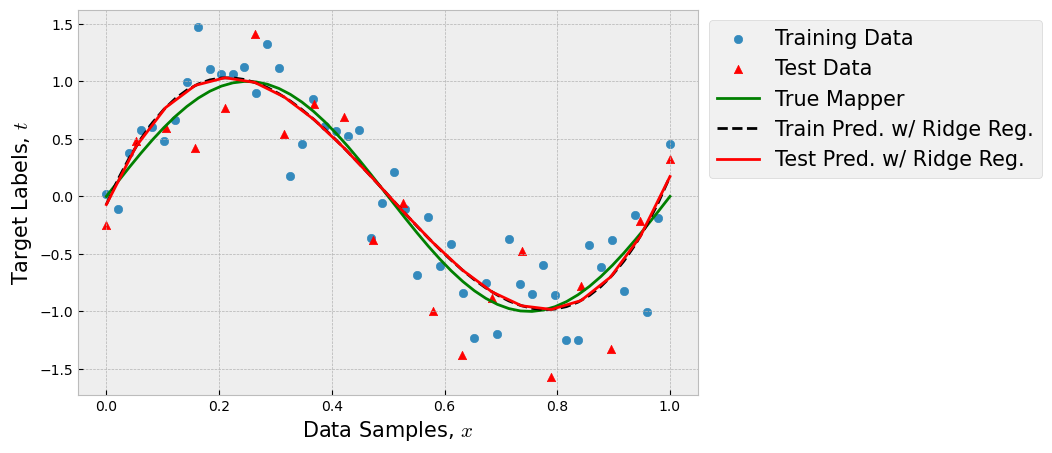

In [21]:
# Plotting results
plt.figure(figsize=(8,5))
plt.scatter(x_train, t_train, label='Training Data')
plt.scatter(x_test, t_test, c='r', marker='^',label='Test Data')
plt.plot(x_true, t_true, 'g', label = 'True Mapper')
plt.plot(x_train, y_train, '--k', label='Train Pred. w/ Ridge Reg.')
plt.plot(x_test, y_test, 'r', label='Test Pred. w/ Ridge Reg.')
plt.legend(fontsize=15,bbox_to_anchor=(1, 1))
plt.xlabel('Data Samples, $x$',size=15)
plt.ylabel('Target Labels, $t$',size=15);

In [22]:
from sklearn.metrics import mean_squared_error

In [23]:
final_rmse_train = np.sqrt(mean_squared_error(t_train, y_train))
print('RMSE Train: ', final_rmse_train)

final_rmse_test = np.sqrt(mean_squared_error(t_test, y_test))
print('RMSE Test: ', final_rmse_test)

RMSE Train:  0.2887176890364383
RMSE Test:  0.38780469601275686


In some cases, such a point estimate of the generalization error will not be quite enough to convince you to launch: what if it is just 0.1% better than the model currently in production? You might want to have an idea of how precise this estimate is. 

For this, you can compute a 95% confidence interval for the generalization error using ```scipy.stats.t.interval()```:

In [24]:
# Import the statistics module from SciPy
from scipy import stats

# Set the confidence level (95% confidence interval)
confidence = 0.95

# Compute squared errors (difference between predicted and actual values squared)
squared_errors = (t_test - y_test) ** 2

# Create a Student's T distribution object:
# - df: Degrees of freedom = number of squared errors - 1
# - loc: Mean of squared errors (center of the distribution)
# - scale: Standard error of the mean, calculated as sqrt(variance / sample size)
T = stats.t(
    df=len(squared_errors) - 1,  # Degrees of freedom
    loc=squared_errors.mean(),  # Mean of the squared errors
    scale=np.sqrt(squared_errors.var() / len(squared_errors))  # Standard error
)

This constructs a Student’s t-distribution with:

- **Degrees of freedom (df)** = \( N - 1 \) (where \( N \) is the number of squared errors).
- **Mean (loc)** = `squared_errors.mean()` (mean squared error).
- **Scale (standard error of the mean)** = (standard deviation of squared errors) / sqrt(N)


This results in a t-distribution centered around the mean squared error (MSE) with an adjusted scale for variance.

Next, we will visualize the **Probability Density Function (PDF)** and the **Cumulative Distribution Function (CDF)** of the T-distribution over a specified range. The PDF represents the likelihood of different squared error values occurring, while the CDF shows the cumulative probability of values being less than or equal to a given threshold. By plotting these functions, the code provides insight into how squared errors are distributed and their cumulative probability, which is useful for statistical analysis and model evaluation.



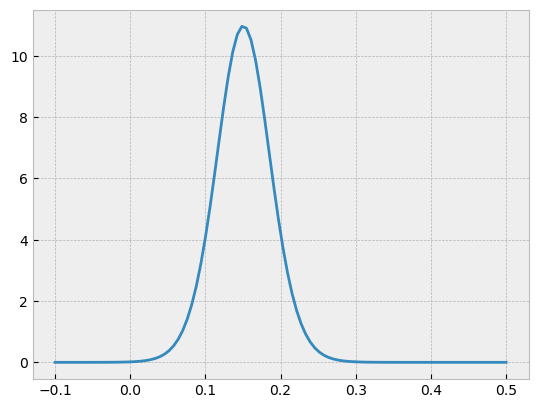

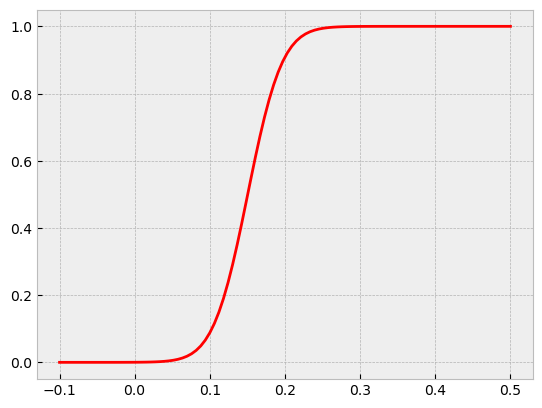

In [25]:

# Generate a range of values for plotting the PDF and CDF of the T-distribution
tline = np.linspace(-0.1, 0.5, 100)  # Generate 100 points from -0.1 to 0.5

# Plot the Probability Density Function (PDF) of the T-distribution
plt.plot(tline, T.pdf(tline))  # PDF shows the likelihood of each squared error value
plt.show()  # Display the plot

# Plot the Cumulative Distribution Function (CDF) of the T-distribution
plt.plot(tline, T.cdf(tline), 'r')  # CDF shows the probability of values being ≤ x





In [ ]:
T

In [26]:
# 95% Confidence interval (CI) for the MSE

T.ppf(0.025), T.ppf(0.975)

(np.float64(0.07531535490954763), np.float64(0.22546960958954587))

In [27]:
# 95% Confidence interval (CI) for the RMSE

np.sqrt(T.ppf(0.025)), np.sqrt(T.ppf(0.975))

(np.float64(0.2744364314546224), np.float64(0.47483640297427265))

In [28]:
# Alternatively, the 95% CI for the RMSE
# This bypasses the need of defining the student's T random variable T

np.sqrt(stats.t.interval(confidence,
                 len(squared_errors)-1, #dof
                loc = squared_errors.mean(), # mean
                scale= np.sqrt(squared_errors.var()/len(squared_errors)))) # std


array([0.27443643, 0.4748364 ])

If you did a lot of hyperparameter tuning, the performance will usually be slightly worse than what you measured using cross-validation (because your system ends up fine-tuned to perform well on the validation data and will likely not perform as well on unknown datasets). It is not the case in this example, but when this happens you must **resist the temptation** to tweak the hyperparameters to make the numbers look good on the test set; the improvements would be unlikely to generalize to new data. 

Now comes the project pre-launch phase: you need to present your solution (highlighting what you have learned, what worked and what did not, what assumptions were made, and what your system's limitations are), document everything, and create nice presentations with clear visualizations and easy-to-remember statements (e.g., "the median income is the number one predictor of housing prices"). If final performance of the system is not better than the experts' current estimates, which may still be off by e.g. 20%, it may still be a good idea to launch it, especially if this frees up some time for the experts so they can work on more interesting and productive tasks.

---